# 📊 Business Understanding

Jaya Jaya Institut menghadapi permasalahan tingginya angka mahasiswa dropout yang berdampak pada kualitas pendidikan dan reputasi institusi.

## 🎯 Permasalahan
- Tingginya angka dropout mahasiswa  
- Tidak adanya sistem early warning  
- Sulit mengidentifikasi faktor utama penyebab dropout  

## 🎯 Tujuan
Membangun model machine learning untuk memprediksi mahasiswa berisiko dropout sehingga institusi dapat melakukan intervensi lebih dini.

## 📌 Cakupan Proyek
- Data Understanding  
- Exploratory Data Analysis (EDA)  
- Data Preparation  
- Modeling  
- Evaluation  
- Deployment  

## Import Library

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

## Load Dataset
Dataset dibaca menggunakan separator ";".

In [50]:
df = pd.read_csv("/content/drive/MyDrive/dicoding/dataset/data_siswa.csv", sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 🔍 Data Understanding
Melihat struktur dataset dan tipe data.

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## 🧹 Data Cleaning

Menghapus data dengan status **Enrolled** agar model fokus pada klasifikasi:
➡️ Dropout vs Graduate

In [52]:
# Membersihkan nama kolom
df.columns = df.columns.str.strip()

# Rename target
df.rename(columns={'Status': 'target'}, inplace=True)

# Hapus Enrolled
df = df[df['target'] != 'Enrolled']

# Mapping target
df['target'] = df['target'].map({
    'Graduate': 0,
    'Dropout': 1
})

df['target'].value_counts()

,count
target,
0,2209
1,1421


## Distribusi Status Mahasiswa

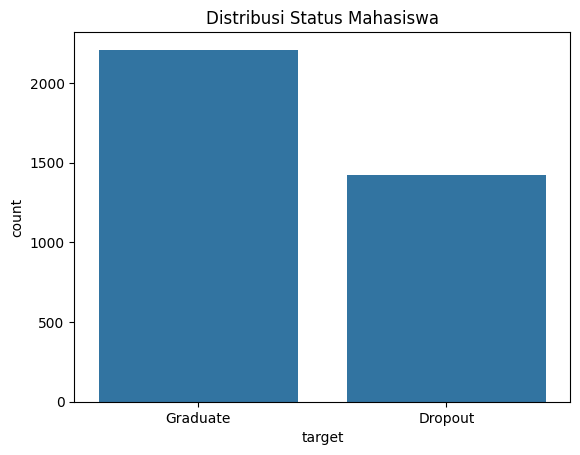

In [53]:
sns.countplot(x='target', data=df)
plt.xticks([0,1], ['Graduate','Dropout'])
plt.title("Distribusi Status Mahasiswa")
plt.show()

### Insight
Proporsi mahasiswa dropout masih cukup signifikan dibandingkan graduate.
Hal ini menunjukkan bahwa dropout merupakan masalah nyata yang perlu ditangani secara sistematis oleh institusi.

## Distribusi Umur Mahasiswa

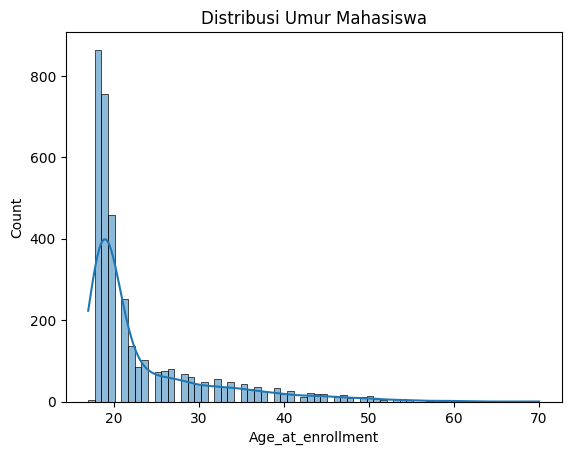

In [54]:
sns.histplot(df['Age_at_enrollment'], kde=True)
plt.title("Distribusi Umur Mahasiswa")
plt.show()

### Insight
Sebagian besar mahasiswa berada pada usia awal perkuliahan.
Namun, mahasiswa dengan usia lebih tinggi menunjukkan variasi yang lebih besar dan berpotensi memiliki risiko dropout lebih tinggi akibat faktor eksternal.

## Distribusi Gender

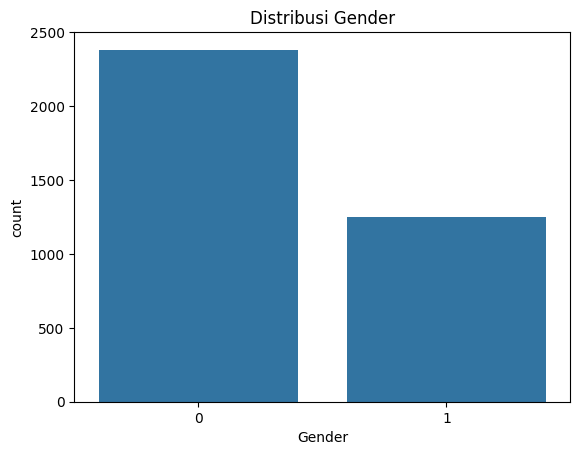

In [55]:
sns.countplot(x='Gender', data=df)
plt.title("Distribusi Gender")
plt.show()

### Insight
Distribusi gender relatif seimbang dan tidak menunjukkan perbedaan signifikan terhadap dropout.
Hal ini menunjukkan bahwa gender bukan faktor utama.

## Admission Grade vs Status

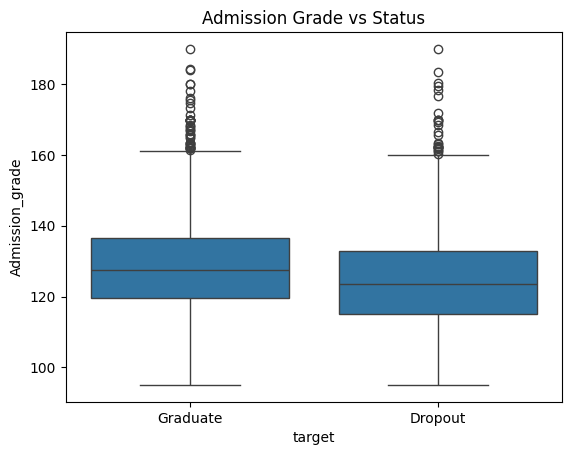

In [56]:
sns.boxplot(x='target', y='Admission_grade', data=df)
plt.xticks([0,1], ['Graduate','Dropout'])
plt.title("Admission Grade vs Status")
plt.show()

### Insight
Mahasiswa dropout memiliki nilai admission grade yang lebih rendah,
namun terdapat overlap distribusi yang besar sehingga variabel ini bukan faktor dominan.

## Status Pembayaran vs Dropout

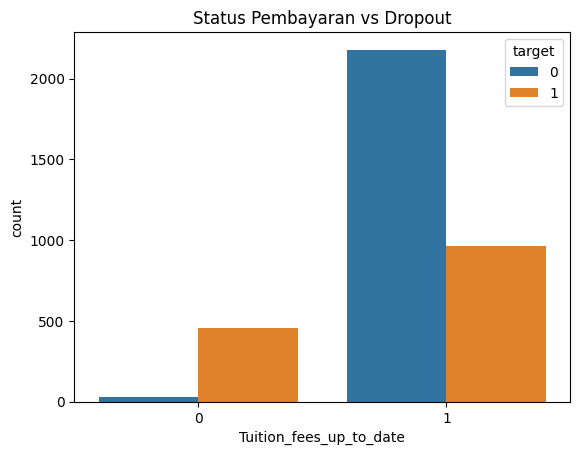

In [57]:
sns.countplot(x='Tuition_fees_up_to_date', hue='target', data=df)
plt.title("Status Pembayaran vs Dropout")
plt.show()

### Insight
Mahasiswa dengan pembayaran tidak lancar memiliki proporsi dropout lebih tinggi.
Hal ini menunjukkan bahwa faktor finansial memiliki pengaruh signifikan.

## Nilai Semester 1 vs Status

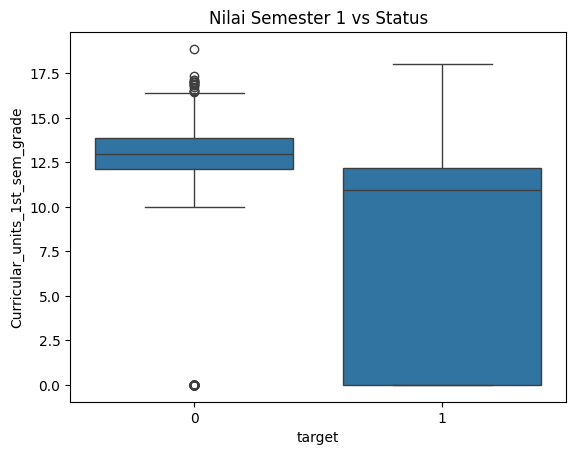

In [58]:
sns.boxplot(x='target', y='Curricular_units_1st_sem_grade', data=df)
plt.title("Nilai Semester 1 vs Status")
plt.show()

### Insight
Mahasiswa dropout memiliki nilai semester pertama yang secara konsisten lebih rendah dibandingkan graduate.
Ini menjadi indikator early warning yang kuat.

## Mata Kuliah Lulus vs Status

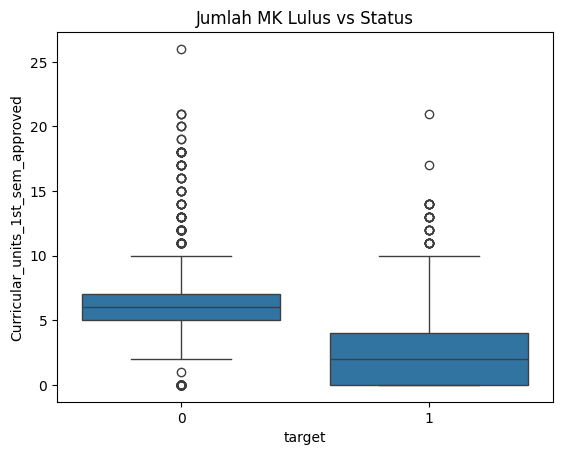

In [59]:
sns.boxplot(x='target', y='Curricular_units_1st_sem_approved', data=df)
plt.title("Jumlah MK Lulus vs Status")
plt.show()

### Insight
Mahasiswa yang menyelesaikan lebih sedikit mata kuliah memiliki risiko dropout lebih tinggi.
Hal ini menunjukkan kesulitan akademik sejak awal.

## 🧠 Insight untuk Modeling

Berdasarkan EDA, faktor utama:
- Performa akademik semester awal  
- Jumlah mata kuliah lulus  
- Status pembayaran  

Faktor ini digunakan sebagai dasar dalam pemodelan.

## ⚙️ Data Preparation

In [60]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 🤖 Modeling

Menggunakan Random Forest karena mampu menangkap pola kompleks pada data.

In [61]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## 📈 Evaluasi Model

In [62]:
y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9022038567493113
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       449
           1       0.91      0.82      0.87       277

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



## 📊 Confusion Matrix

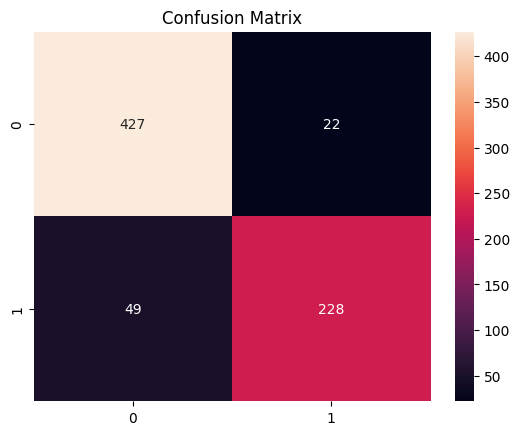

In [63]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Insight
Model mampu mengklasifikasikan mayoritas data dengan baik,
meskipun masih terdapat kesalahan pada prediksi dropout.

## 📊 Feature Importance

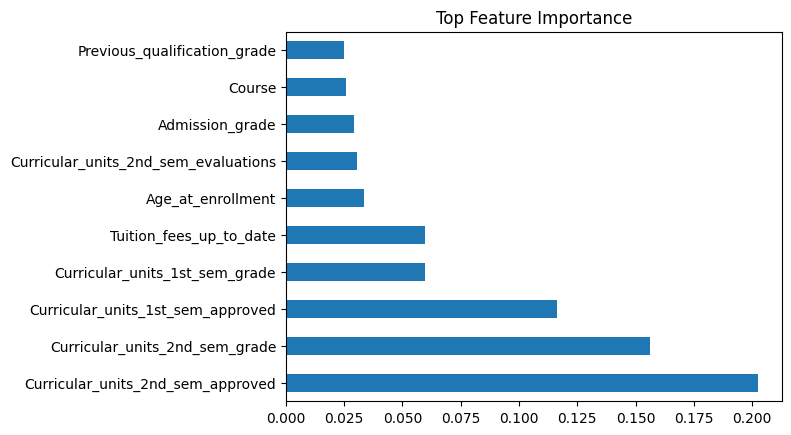

In [64]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

### Insight
Fitur yang paling berpengaruh adalah performa akademik semester awal dan jumlah mata kuliah lulus.
Hal ini konsisten dengan hasil EDA.

## 💾 Save Model

In [65]:
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

## 🎯 Conclusion

Faktor utama dropout:
- Performa akademik semester awal  
- Jumlah mata kuliah lulus  
- Status pembayaran  

Admission grade tidak dominan.

Model memiliki performa yang baik dan dapat digunakan sebagai early warning system.

## 💡 Rekomendasi

- Implementasi sistem early warning  
- Monitoring performa semester awal  
- Program mentoring akademik  
- Bantuan finansial bagi mahasiswa  
- Monitoring pembayaran  

## Keterbatasan

Model masih dapat ditingkatkan melalui hyperparameter tuning dan penambahan fitur.